In [55]:
!pip install geopandas pandas matplotlib contextily folium mapclassify libpysal esda statsmodels fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 18.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fiona]32m1/2 [fiona]


## 1. Library Imports and Path Definitions

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import folium
import fiona

print("All libraries loaded successfully")

gpkg_path = "/mnt/e/Portfolio Files/nebraska-soil-project/ncss_labdata.gpkg"

All libraries loaded successfully


## 2. Load County Boundaries

In [28]:
import geopandas as gpd
url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"
# Load Nebraska county boundaries directly from Census TIGER
nebraska = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)

# Filter to Nebraska (state FIPS code is 31)
nebraska = nebraska[nebraska['STATEFP'] == '31']

print(f"Loaded {len(nebraska)} counties")
nebraska.head()

Loaded 93 counties


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."
40,31,101,00835872,31101,0500000US31101,Keith,Keith County,06,H1,G4020,NaN,NaN,NaN,A,2750729944,123802447,+41.1942448,-101.6444493,"POLYGON ((-102.05546 41.29967, -102.05545 41.3..."
41,31,137,00835890,31137,0500000US31137,Phelps,Phelps County,06,H1,G4020,NaN,NaN,NaN,A,1397985736,1709313,+40.5163647,-099.4065568,"POLYGON ((-99.17949 40.52501, -99.17948 40.524..."


## 3. County Plot - Confirms Data loaded correctly

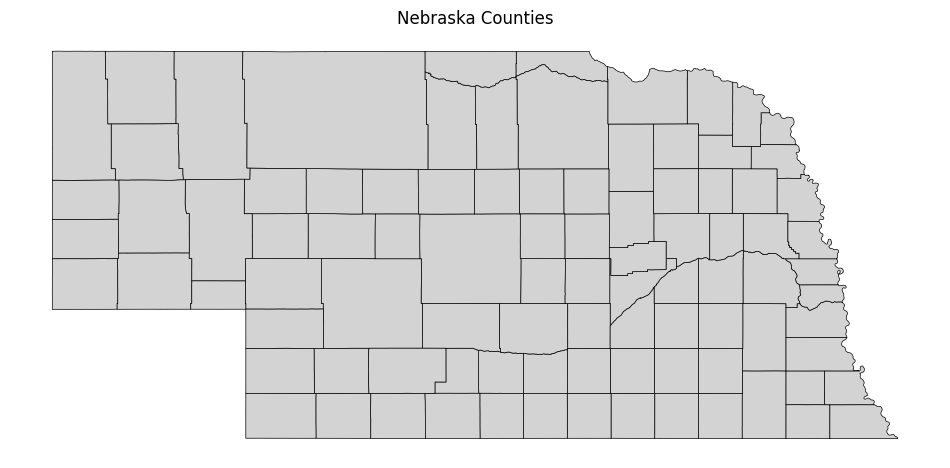

In [29]:
nebraska.plot(figsize=(12, 6), color='lightgrey', edgecolor='black', linewidth=0.5)
plt.title("Nebraska Counties")
plt.axis('off')
plt.show()

## 4. Define API Endpoint and Query Soil pH Data

In [30]:
import requests
import json

url = "https://SDMDataAccess.sc.egov.usda.gov/Tabular/post.rest"

query_ph = """SELECT l.areasymbol, l.areaname, mu.musym, mu.muname, 
           co.comppct_r, hz.ph1to1h2o_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.ph1to1h2o_r IS NOT NULL"""

payload = {"query": query_ph, "format": "json+columnname"}
response = requests.post(url, data=payload)

data = response.json()
rows = data['Table']
headers = rows[0]
df = pd.DataFrame(rows[1:], columns=headers)
df['ph1to1h2o_r'] = pd.to_numeric(df['ph1to1h2o_r'])

print(f"Loaded {len(df)} soil records")
df.head()

Loaded 77328 soil records


,areasymbol,areaname,musym,muname,comppct_r,ph1to1h2o_r
0,NE031,"Cherry County, Nebraska",5267,"Tuthill fine sandy loam, 6 to 9 percent slopes",90,7.9
1,NE031,"Cherry County, Nebraska",5267,"Tuthill fine sandy loam, 6 to 9 percent slopes",90,7.9
2,NE031,"Cherry County, Nebraska",5267,"Tuthill fine sandy loam, 6 to 9 percent slopes",90,7.0
3,NE031,"Cherry County, Nebraska",5267,"Tuthill fine sandy loam, 6 to 9 percent slopes",90,7.0
4,NE015,"Boyd County, Nebraska",3305,"Reliance silt loam, 2 to 6 percent slopes",85,7.1


## 5. Calculate Weighted Average Soil pH by County

In [31]:
# Extract county name and calculate weighted average pH per county
df['comppct_r'] = pd.to_numeric(df['comppct_r'])

# Pull clean county name from areaname (remove ", Nebraska")
df['county'] = df['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average pH by county
county_ph = df.groupby('county').apply(
    lambda x: (x['ph1to1h2o_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()

county_ph.columns = ['county', 'avg_ph']
county_ph = county_ph.sort_values('avg_ph', ascending=False)

print(f"{len(county_ph)} counties with pH data")
county_ph.head(10)

93 counties with pH data


,county,avg_ph
28,Dundy County,7.794262
78,Scotts Bluff County,7.741405
43,Hitchcock County,7.737147
72,Red Willow County,7.629928
22,Dawes County,7.621980
82,Sioux County,7.607287
42,Hayes County,7.586606
3,Banner County,7.556212
32,Furnas County,7.541582
14,Chase County,7.533247


## 6. Merge pH Data onto County Boundaries

In [32]:
# Standardize county names for joining
nebraska['county'] = nebraska['NAME'] + ' County'

# Merge pH data onto county shapes
nebraska_ph = nebraska.merge(county_ph, on='county', how='left')

print(f"Counties with pH data: {nebraska_ph['avg_ph'].notna().sum()}")
print(f"Counties missing pH data: {nebraska_ph['avg_ph'].isna().sum()}")
nebraska_ph[['county', 'avg_ph']].head(10)

Counties with pH data: 92
Counties missing pH data: 1


,county,avg_ph
0,Cuming County,7.205059
1,Lancaster County,6.877413
2,Nuckolls County,7.117788
3,Keith County,7.458775
4,Phelps County,7.294694
5,Webster County,7.348759
6,Dakota County,7.470700
7,Boyd County,7.179913
8,Thomas County,6.730216
9,Holt County,6.855689


## 7. Plot Soil pH by County

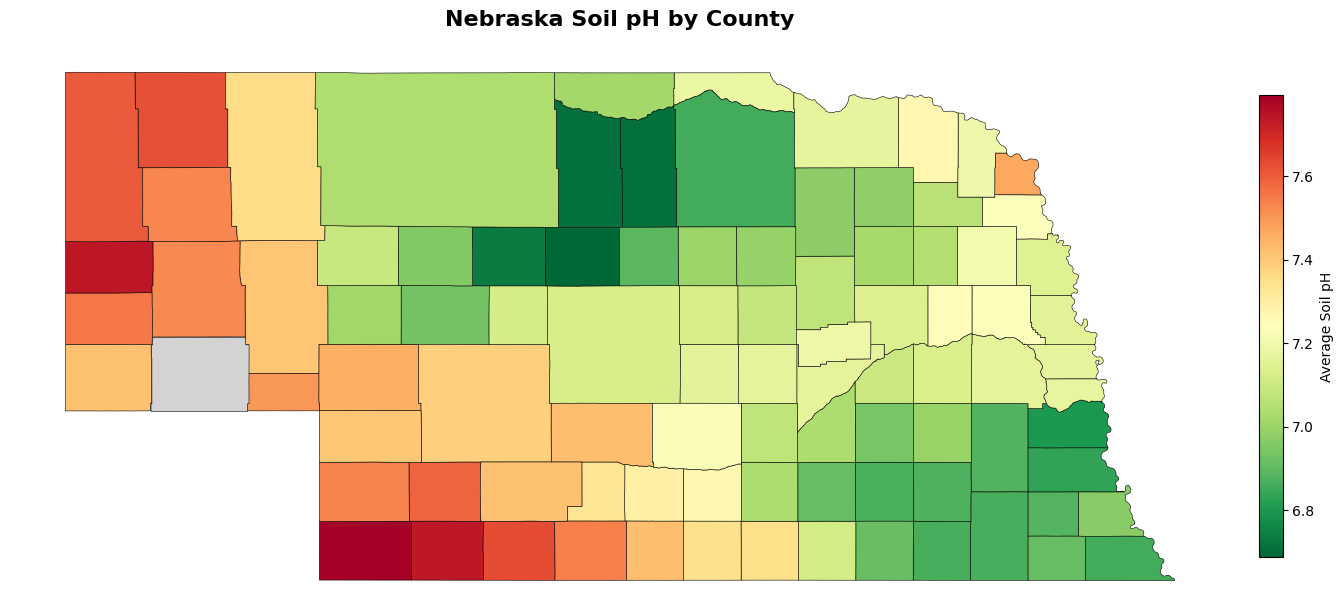

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={
        'label': 'Average Soil pH',
       # 'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

ax.set_title('Nebraska Soil pH by County', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('nebraska_soil_ph.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Query Organic Matter

In [34]:
query_p = """SELECT l.areasymbol, l.areaname, 
           co.comppct_r, hz.ph1to1h2o_r, hz.om_r
           FROM legend l
           JOIN mapunit mu ON mu.lkey = l.lkey
           JOIN component co ON co.mukey = mu.mukey
           JOIN chorizon hz ON hz.cokey = co.cokey
           WHERE l.areasymbol LIKE 'NE%'
           AND hz.om_r IS NOT NULL"""

payload_p = {"query": query_p, "format": "json+columnname"}

response_p = requests.post(url, data=payload_p)
print(response_p.status_code)
print(response_p.text[:500])

200
{"Table":[["areasymbol","areaname","comppct_r","ph1to1h2o_r","om_r"],["NE103","Keya Paha County, Nebraska","100","7","2"],["NE103","Keya Paha County, Nebraska","100","7.5","1"],["NE103","Keya Paha County, Nebraska","100",null,"0.25"],["NE107","Knox County, Nebraska","3","7.3","0.25"],["NE107","Knox County, Nebraska","3","7.9","0.5"],["NE107","Knox County, Nebraska","3","7.9","0.75"],["NE107","Knox County, Nebraska","3","7.5","3"],["NE107","Knox County, Nebraska","3","6.5","0.25"],["NE107","Knox 


## 9. Parse and Aggregate Organic Matter Data

In [35]:
# Parse organic matter response
data_p = response_p.json()
rows_p = data_p['Table']
headers_p = rows_p[0]
df_p = pd.DataFrame(rows_p[1:], columns=headers_p)

# Convert to numeric
df_p['comppct_r'] = pd.to_numeric(df_p['comppct_r'])
df_p['om_r'] = pd.to_numeric(df_p['om_r'])

# Clean county name
df_p['county'] = df_p['areaname'].str.replace(', Nebraska', '', regex=False).str.strip()

# Weighted average organic matter by county
county_om = df_p.groupby('county').apply(
    lambda x: (x['om_r'] * x['comppct_r']).sum() / x['comppct_r'].sum()
).reset_index()
county_om.columns = ['county', 'avg_om']

# Add sample counts for both datasets
ph_counts = df.groupby('county').size().reset_index(name='ph_count')
om_counts = df_p.groupby('county').size().reset_index(name='om_count')
county_ph_full = county_ph.merge(ph_counts, on='county')
county_om_full = county_om.merge(om_counts, on='county')

print(f"{len(county_om_full)} counties with organic matter data")
county_om_full.sort_values('avg_om', ascending=False).head(10)

93 counties with organic matter data


,county,avg_om,om_count
2,Arthur County,8.614317,521
45,Hooker County,6.549674,564
37,Grant County,6.232505,611
59,McPherson County,5.192270,528
15,Cherry County,4.001681,1307
34,Garden County,2.365315,848
80,Sheridan County,2.279544,1399
91,Wheeler County,2.132966,653
6,Box Butte County,2.030089,1164
92,York County,2.024610,477


## 10. Merge OM onto County Boundaries and Create Combined Dataset

In [36]:
# Merge pH and OM onto county shapes
nebraska_om = nebraska.merge(county_om_full, on='county', how='left')
nebraska_combined = nebraska_ph.merge(
    nebraska_om[['county', 'avg_om']], 
    on='county', 
    how='left'
)

## 11. Two-Panel Soil Chemistry Map

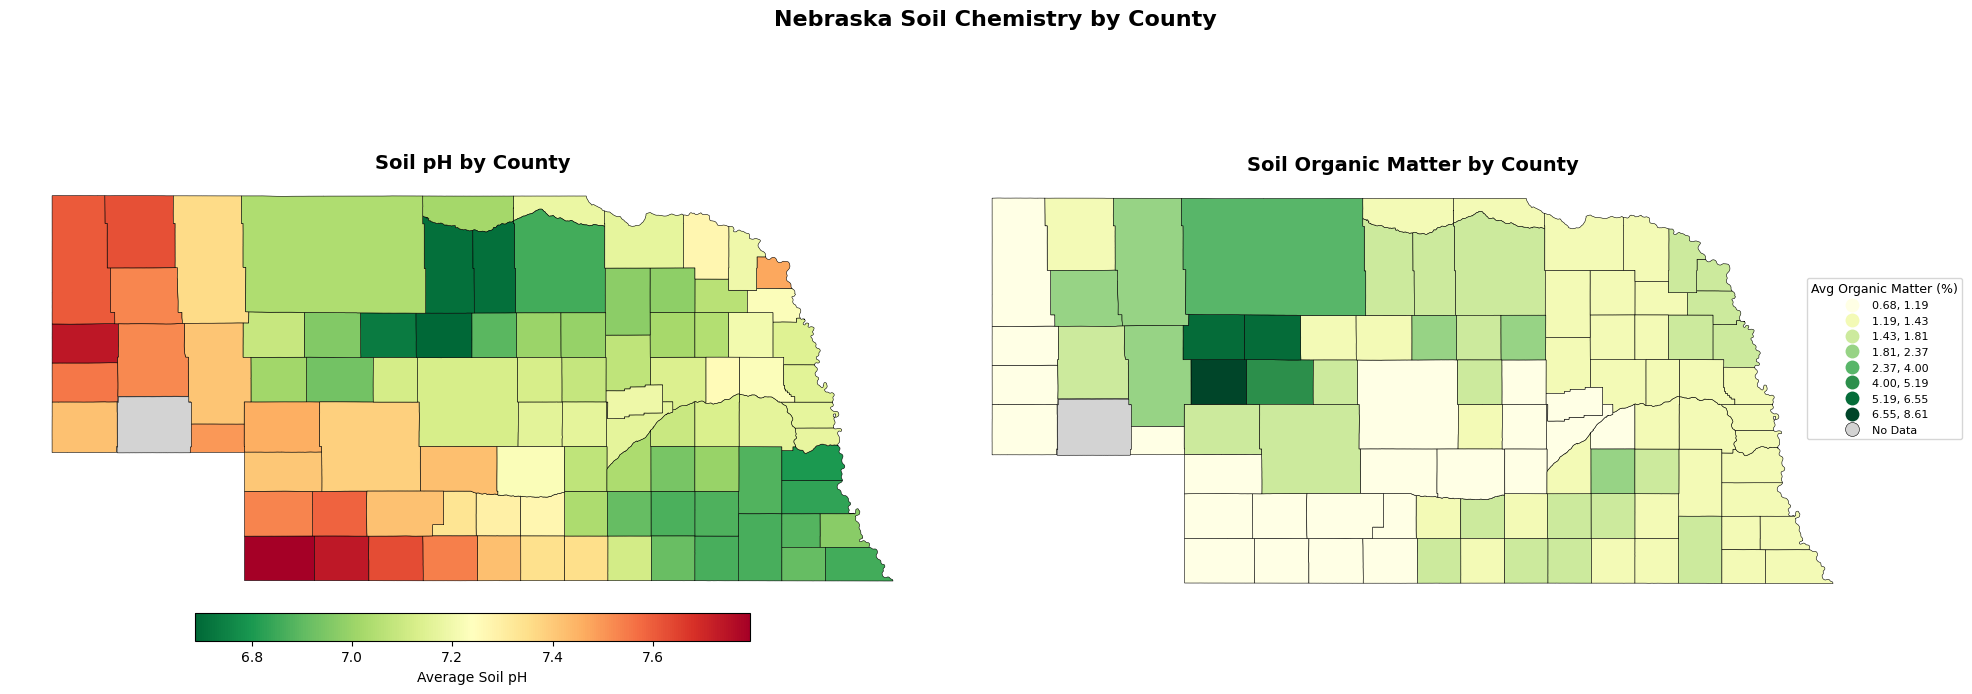

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

nebraska_ph.plot(
    column='avg_ph',
    ax=ax1,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Average Soil pH', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
)
ax1.set_title('Soil pH by County', fontsize=14, fontweight='bold')
ax1.set_axis_off()

nebraska_combined.plot(
    column='avg_om',
    ax=ax2,
    cmap='YlGn',
    scheme='natural_breaks',
    k=8,
    legend=True,
    legend_kwds={
        'title': 'Avg Organic Matter (%)',
        'loc': 'upper left',
        'bbox_to_anchor': (0.92, 0.78),
        'fontsize': 8,
        'title_fontsize': 9,
        'frameon': True
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
)
ax2.set_title('Soil Organic Matter by County', fontsize=14, fontweight='bold')
ax2.set_axis_off()

fig.suptitle('Nebraska Soil Chemistry by County', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nebraska_soil_ph_om.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. MLRA Query, Parse into GeoDataFrame

In [38]:
# Fetch MLRA data including eastern Nebraska (LRR M)
mlra_url = "https://services.arcgis.com/SXbDpmb7xQkk44JV/arcgis/rest/services/MLRA_52/FeatureServer/0/query"

params = {
    "where": "LRRSYM IN ('F', 'G', 'H', 'M')",
    "outFields": "MLRARSYM,MLRA_NAME,LRRSYM",
    "f": "geojson",
    "outSR": "4326"
}

response_mlra = requests.get(mlra_url, params=params)

mlra = gpd.GeoDataFrame.from_features(
    json.loads(response_mlra.text)['features'],
    crs='EPSG:4326'
)

# Dissolve Nebraska counties into state boundary and clip MLRAs
nebraska_boundary = nebraska.dissolve().to_crs('EPSG:4326')
mlra_ne = gpd.clip(mlra, nebraska_boundary)

print(f"{len(mlra_ne)} MLRAs intersecting Nebraska")
print(mlra_ne['MLRA_NAME'].unique())

15 MLRAs intersecting Nebraska
<StringArray>
[                   'Rolling Plains and Breaks',
                         'Central Loess Plains',
                       'Central High Tableland',
           'Central High Plains, Northern Part',
 'Mixed Sandy and Silty Tableland and Badlands',
               'Central Kansas Sandstone Hills',
        'Nebraska and Kansas Loess-Drift Hills',
           'Iowa and Missouri Deep Loess Hills',
                                'Loess Uplands',
                 'Central Nebraska Loess Hills',
                          'Nebraska Sand Hills',
             'Dakota-Nebraska Eroded Tableland',
         'Southern Rolling Pierre Shale Plains',
              'Southern Black Glaciated Plains',
                          'Pierre Shale Plains']
Length: 15, dtype: str


## 13. Dissolve, Clip to Nebraska Counties

In [39]:
# Dissolve Nebraska counties into a single state boundary
nebraska_boundary = nebraska.dissolve().to_crs('EPSG:4326')

# Clip MLRAs to Nebraska
mlra_ne = gpd.clip(mlra, nebraska_boundary)

print(f"{len(mlra_ne)} MLRAs intersecting Nebraska")
print(mlra_ne['MLRA_NAME'].unique())

15 MLRAs intersecting Nebraska
<StringArray>
[                   'Rolling Plains and Breaks',
                         'Central Loess Plains',
                       'Central High Tableland',
           'Central High Plains, Northern Part',
 'Mixed Sandy and Silty Tableland and Badlands',
               'Central Kansas Sandstone Hills',
        'Nebraska and Kansas Loess-Drift Hills',
           'Iowa and Missouri Deep Loess Hills',
                                'Loess Uplands',
                 'Central Nebraska Loess Hills',
                          'Nebraska Sand Hills',
             'Dakota-Nebraska Eroded Tableland',
         'Southern Rolling Pierre Shale Plains',
              'Southern Black Glaciated Plains',
                          'Pierre Shale Plains']
Length: 15, dtype: str


## 14. MLRA Reference Map

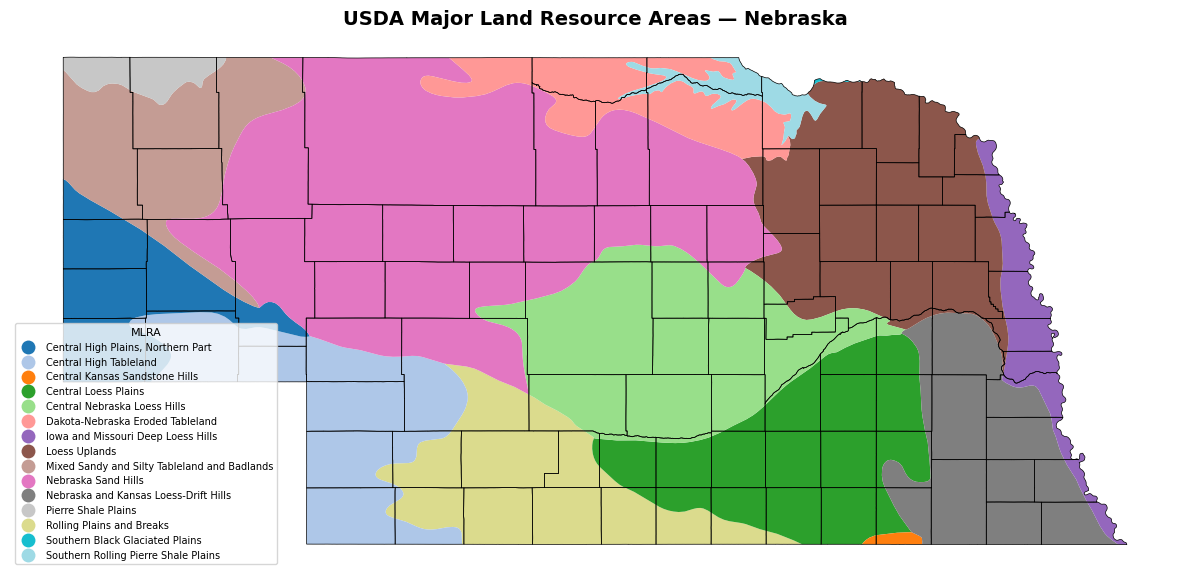

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

mlra_ne.plot(
    column='MLRA_NAME',
    ax=ax,
    cmap='tab20',
    edgecolor='none',
    legend=True,
    legend_kwds={'loc': 'lower left', 'fontsize': 7, 'title': 'MLRA', 'title_fontsize': 8}
)

nebraska.to_crs('EPSG:4326').plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('USDA Major Land Resource Areas — Nebraska', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 15. Assign Dominant MLRA to Each County

In [41]:
# Merge pH and OM data together into one geodataframe
nebraska_combined = nebraska_ph.merge(
    nebraska_om[['county', 'avg_om']], 
    on='county', 
    how='left'
)

# Reproject both to projected CRS
nebraska_combined_proj = nebraska_combined.to_crs('EPSG:32614')
mlra_ne_proj = mlra_ne.to_crs('EPSG:32614')

# Overlay to get intersection areas
county_mlra_overlay = gpd.overlay(
    nebraska_combined_proj[['county', 'avg_ph', 'avg_om', 'geometry']], 
    mlra_ne_proj[['MLRA_NAME', 'geometry']], 
    how='intersection'
)

# Calculate area and keep dominant MLRA per county
county_mlra_overlay['area'] = county_mlra_overlay.geometry.area
dominant_mlra = county_mlra_overlay.loc[county_mlra_overlay.groupby('county')['area'].idxmax()]
dominant_mlra = dominant_mlra[['county', 'MLRA_NAME', 'avg_ph', 'avg_om']].reset_index(drop=True)

print(f"Counties with dominant MLRA assigned: {len(dominant_mlra)}")
dominant_mlra.head(10)

Counties with dominant MLRA assigned: 93


,county,MLRA_NAME,avg_ph,avg_om
0,Adams County,Central Loess Plains,7.034459,1.310714
1,Antelope County,Loess Uplands,6.976148,1.337979
2,Arthur County,Nebraska Sand Hills,7.011766,8.614317
3,Banner County,"Central High Plains, Northern Part",7.556212,1.077763
4,Blaine County,Nebraska Sand Hills,6.686396,1.374729
5,Boone County,Loess Uplands,7.072675,1.234803
6,Box Butte County,Mixed Sandy and Silty Tableland and Badlands,7.527504,2.030089
7,Boyd County,Southern Rolling Pierre Shale Plains,7.179913,1.218084
8,Brown County,Nebraska Sand Hills,6.707081,1.663342
9,Buffalo County,Central Nebraska Loess Hills,7.225797,1.100427


## 16. Correlation Analysis - pH vs Organic Matter

In [42]:
from scipy import stats

# Pearson correlation between pH and organic matter
r, p_value = stats.pearsonr(
    dominant_mlra['avg_ph'].dropna(),
    dominant_mlra['avg_om'].dropna()
)

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p_value:.4f}")

Pearson r: -0.200
p-value: 0.0562


## 17. Generate Scatter Plots

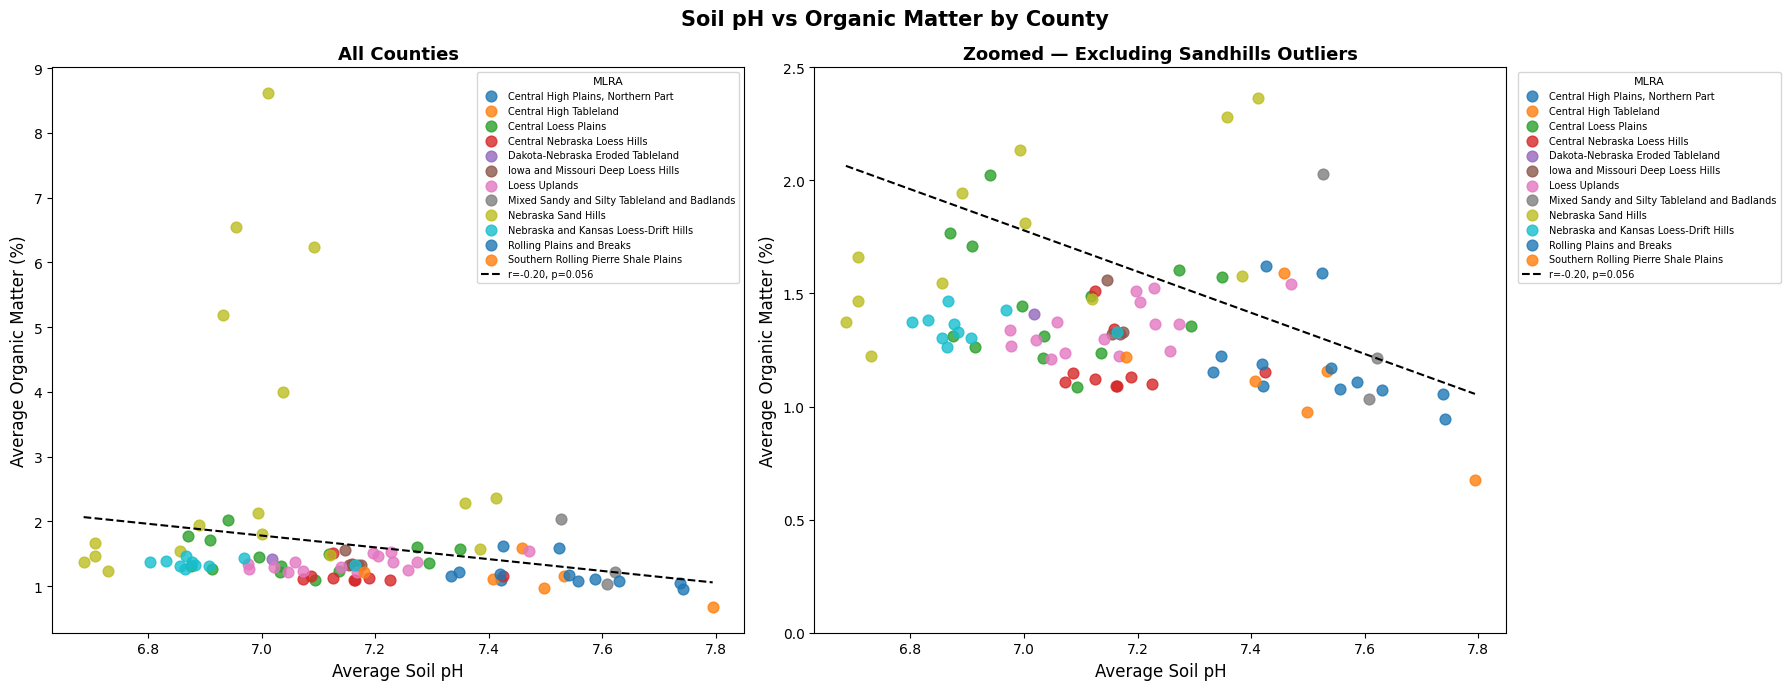

In [43]:
from scipy import stats
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Full plot
for mlra_name, group in dominant_mlra.groupby('MLRA_NAME'):
    ax1.scatter(group['avg_ph'], group['avg_om'], label=mlra_name, s=60, alpha=0.8)

ax1.set_xlabel('Average Soil pH', fontsize=12)
ax1.set_ylabel('Average Organic Matter (%)', fontsize=12)
ax1.set_title('All Counties', fontsize=13, fontweight='bold')
ax1.legend(fontsize=7, loc='upper right', title='MLRA', title_fontsize=8)

# Zoomed plot
for mlra_name, group in dominant_mlra.groupby('MLRA_NAME'):
    ax2.scatter(group['avg_ph'], group['avg_om'], label=mlra_name, s=60, alpha=0.8)

ax2.set_xlabel('Average Soil pH', fontsize=12)
ax2.set_ylabel('Average Organic Matter (%)', fontsize=12)
ax2.set_title('Zoomed — Excluding Sandhills Outliers', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 2.5)
ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1), title='MLRA', title_fontsize=8, frameon=True)

fig.suptitle('Soil pH vs Organic Matter by County', fontsize=15, fontweight='bold')

# Calculate regression line
slope, intercept, r, p, se = stats.linregress(dominant_mlra['avg_ph'], dominant_mlra['avg_om'])

# Add regression line to both plots
clean = dominant_mlra[['avg_ph', 'avg_om']].dropna()
slope, intercept, r, p, se = stats.linregress(clean['avg_ph'], clean['avg_om'])
x_line = np.linspace(clean['avg_ph'].min(), clean['avg_ph'].max(), 100)
y_line = slope * x_line + intercept

ax1.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--', label=f'r={r:.2f}, p={p:.3f}')
ax1.legend(fontsize=7, loc='upper right', title='MLRA', title_fontsize=8)

ax2.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--', label=f'r={r:.2f}, p={p:.3f}')
ax2.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1), title='MLRA', title_fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig('nebraska_ph_om_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 18. Linear Regression Output

In [44]:
print("Linear Regression: Organic Matter ~ Soil pH")
print(f"  Slope:      {slope:.4f}")
print(f"  Intercept:  {intercept:.4f}")
print(f"  R²:         {r**2:.4f}")
print(f"  p-value:    {p:.4f}")
print(f"  Std Error:  {se:.4f}")
print(f"         ")
print(f"  For every 1 unit increase in pH, OM decreases by {abs(slope):.3f}%")
print(f"  pH explains {r**2*100:.1f}% of the variation in organic matter across counties")

Linear Regression: Organic Matter ~ Soil pH
  Slope:      -0.9102
  Intercept:  8.1507
  R²:         0.0399
  p-value:    0.0562
  Std Error:  0.4705
         
  For every 1 unit increase in pH, OM decreases by 0.910%
  pH explains 4.0% of the variation in organic matter across counties


## 20. Moran's I for pH

In [45]:
from libpysal.weights import Queen
from esda.moran import Moran

# Need the spatial dataframe with pH values — reproject to match
nebraska_ph_proj = nebraska_combined.to_crs('EPSG:32614')

# Drop the county with missing pH
nebraska_ph_clean = nebraska_ph_proj.dropna(subset=['avg_ph'])

# Build spatial weights matrix (Queen contiguity - shared border or corner)
w = Queen.from_dataframe(nebraska_ph_clean, use_index=True)
w.transform = 'r'  # Row standardize

# Run Moran's I for pH
moran_ph = Moran(nebraska_ph_clean['avg_ph'], w)

print("Moran's I — Soil pH")
print(f"  I statistic:  {moran_ph.I:.4f}")
print(f"  p-value:      {moran_ph.p_sim:.4f}")
print(f"  z-score:      {moran_ph.z_sim:.4f}")

Moran's I — Soil pH
  I statistic:  0.7804
  p-value:      0.0010
  z-score:      12.6029


## 21. Moran's I For Organic Matter

In [46]:
# Run Moran's I for organic matter
nebraska_om_clean = nebraska_ph_proj.dropna(subset=['avg_om'])
w_om = Queen.from_dataframe(nebraska_om_clean, use_index=True)
w_om.transform = 'r'

moran_om = Moran(nebraska_om_clean['avg_om'], w_om)

print("Moran's I — Organic Matter")
print(f"  I statistic:  {moran_om.I:.4f}")
print(f"  p-value:      {moran_om.p_sim:.4f}")
print(f"  z-score:      {moran_om.z_sim:.4f}")

Moran's I — Organic Matter
  I statistic:  0.5489
  p-value:      0.0010
  z-score:      9.3069


## 22. One-way ANOVA to check if pHs in MLRAs are significantly different

In [47]:
from scipy import stats

# Group counties by MLRA
mlra_groups_ph = [group['avg_ph'].dropna().values for name, group in dominant_mlra.groupby('MLRA_NAME')]
mlra_groups_om = [group['avg_om'].dropna().values for name, group in dominant_mlra.groupby('MLRA_NAME')]

# One-way ANOVA
f_stat_ph, p_val_ph = stats.f_oneway(*mlra_groups_ph)
f_stat_om, p_val_om = stats.f_oneway(*mlra_groups_om)

print("One-Way ANOVA — Soil pH by MLRA")
print(f"  F-statistic: {f_stat_ph:.3f}")
print(f"  p-value:     {p_val_ph:.6f}")

print(f"\nOne-Way ANOVA — Organic Matter by MLRA")
print(f"  F-statistic: {f_stat_om:.3f}")
print(f"  p-value:     {p_val_om:.6f}")

One-Way ANOVA — Soil pH by MLRA
  F-statistic: 15.786
  p-value:     0.000000

One-Way ANOVA — Organic Matter by MLRA
  F-statistic: 3.636
  p-value:     0.000339


## 23. Tukey's HSD Post-Hoc Test

In [51]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD for pH
tukey_ph = pairwise_tukeyhsd(
    endog=dominant_mlra['avg_ph'].dropna(),
    groups=dominant_mlra.loc[dominant_mlra['avg_ph'].notna(), 'MLRA_NAME'],
    alpha=0.05
)

# Tukey HSD for organic matter
tukey_om = pairwise_tukeyhsd(
    endog=dominant_mlra['avg_om'].dropna(),
    groups=dominant_mlra.loc[dominant_mlra['avg_om'].notna(), 'MLRA_NAME'],
    alpha=0.05
)

print("Tukey HSD complete for both pH and organic matter.")

Tukey HSD complete for both pH and organic matter.


## 24. Significant MLRA Pairwise Differences

In [52]:
# Significant pH pairs
tukey_ph_df = pd.DataFrame(data=tukey_ph._results_table.data[1:],
                            columns=tukey_ph._results_table.data[0])
significant_ph = tukey_ph_df[tukey_ph_df['reject'] == True]

print(f"=== Significant Soil pH Differences Between MLRAs ({len(significant_ph)} pairs) ===")
print(significant_ph[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))

# Significant OM pairs
tukey_om_df = pd.DataFrame(data=tukey_om._results_table.data[1:],
                            columns=tukey_om._results_table.data[0])
significant_om = tukey_om_df[tukey_om_df['reject'] == True]

print(f"\n=== Significant Organic Matter Differences Between MLRAs ({len(significant_om)} pairs) ===")
print(significant_om[['group1', 'group2', 'meandiff', 'p-adj']].to_string(index=False))

=== Significant Soil pH Differences Between MLRAs (26 pairs) ===
                                      group1                                       group2  meandiff  p-adj
          Central High Plains, Northern Part                         Central Loess Plains   -0.5012 0.0000
          Central High Plains, Northern Part                 Central Nebraska Loess Hills   -0.3872 0.0033
          Central High Plains, Northern Part           Iowa and Missouri Deep Loess Hills   -0.3995 0.0215
          Central High Plains, Northern Part                                Loess Uplands   -0.4060 0.0007
          Central High Plains, Northern Part                          Nebraska Sand Hills   -0.5682 0.0000
          Central High Plains, Northern Part        Nebraska and Kansas Loess-Drift Hills   -0.6586 0.0000
                      Central High Tableland                         Central Loess Plains   -0.4786 0.0000
                      Central High Tableland                 Central Nebraska L

## 25. Load and Filter NCSS Pedon Sampling Sites

In [ ]:
# Load site layer and filter to Nebraska
lab_site = gpd.read_file(gpkg_path, layer='lab_site')

ne_sites = lab_site[
    (lab_site['latitude_std_decimal_degrees'] >= 40.0) &
    (lab_site['latitude_std_decimal_degrees'] <= 43.0) &
    (lab_site['longitude_std_decimal_degrees'] >= -104.0) &
    (lab_site['longitude_std_decimal_degrees'] <= -95.3)
].copy()

ne_sites_gdf = gpd.GeoDataFrame(
    ne_sites,
    geometry=gpd.points_from_xy(
        ne_sites['longitude_std_decimal_degrees'],
        ne_sites['latitude_std_decimal_degrees']
    ),
    crs='EPSG:4326'
)

ne_sites_clipped = gpd.clip(ne_sites_gdf, nebraska_boundary)
print(f"Sites within Nebraska boundary: {len(ne_sites_clipped)}")

Sites within Nebraska boundary: 2305


## 26. NCSS Sampling Site Map

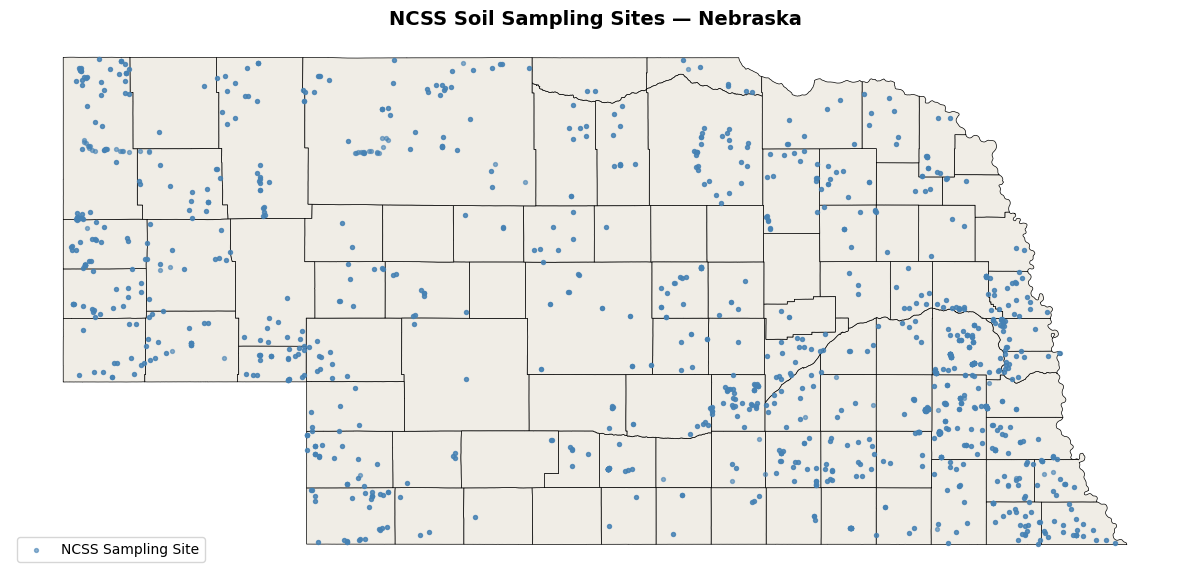

In [ ]:
# Plot sampling sites over county boundaries
fig, ax = plt.subplots(figsize=(12, 6))

nebraska.to_crs('EPSG:4326').plot(
    ax=ax,
    facecolor='#f0ede6',
    edgecolor='black',
    linewidth=0.5
)

ne_sites_clipped.plot(
    ax=ax,
    color='steelblue',
    markersize=8,
    alpha=0.6,
    label='NCSS Sampling Site'
)

ax.set_title('NCSS Soil Sampling Sites — Nebraska', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('nebraska_sampling_sites.png', dpi=300, bbox_inches='tight')
plt.show()